In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load data
data = np.loadtxt('../data/MLoGPU_data3_train.csv', delimiter=',')
X = data[:, :-1]
y = data[:, -1]

# Take all classes
classes = np.unique(y)
classes = classes.astype(int).tolist()

In [ ]:
# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3000, 7) (1000, 7) (3000,) (1000,)


In [45]:
# No train needed for kNN

In [ ]:
# Compute Euclidean distance of test point to all train points
def compute_distances(X_train, y_train, X_test_point):
    distances = []
    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((np.array(X_train[i]) - np.array(X_test_point))**2))
        distances.append((dist, y_train[i]))
       
    # Sort by closest samples 
    distances.sort(key=lambda x: x[0])
    return distances

In [ ]:
# Collect all test distances
dists = []
for i in range(len(X_test)):
    dists.append(compute_distances(X_train, y_train, X_test[i]))
    
dists = np.array(dists)

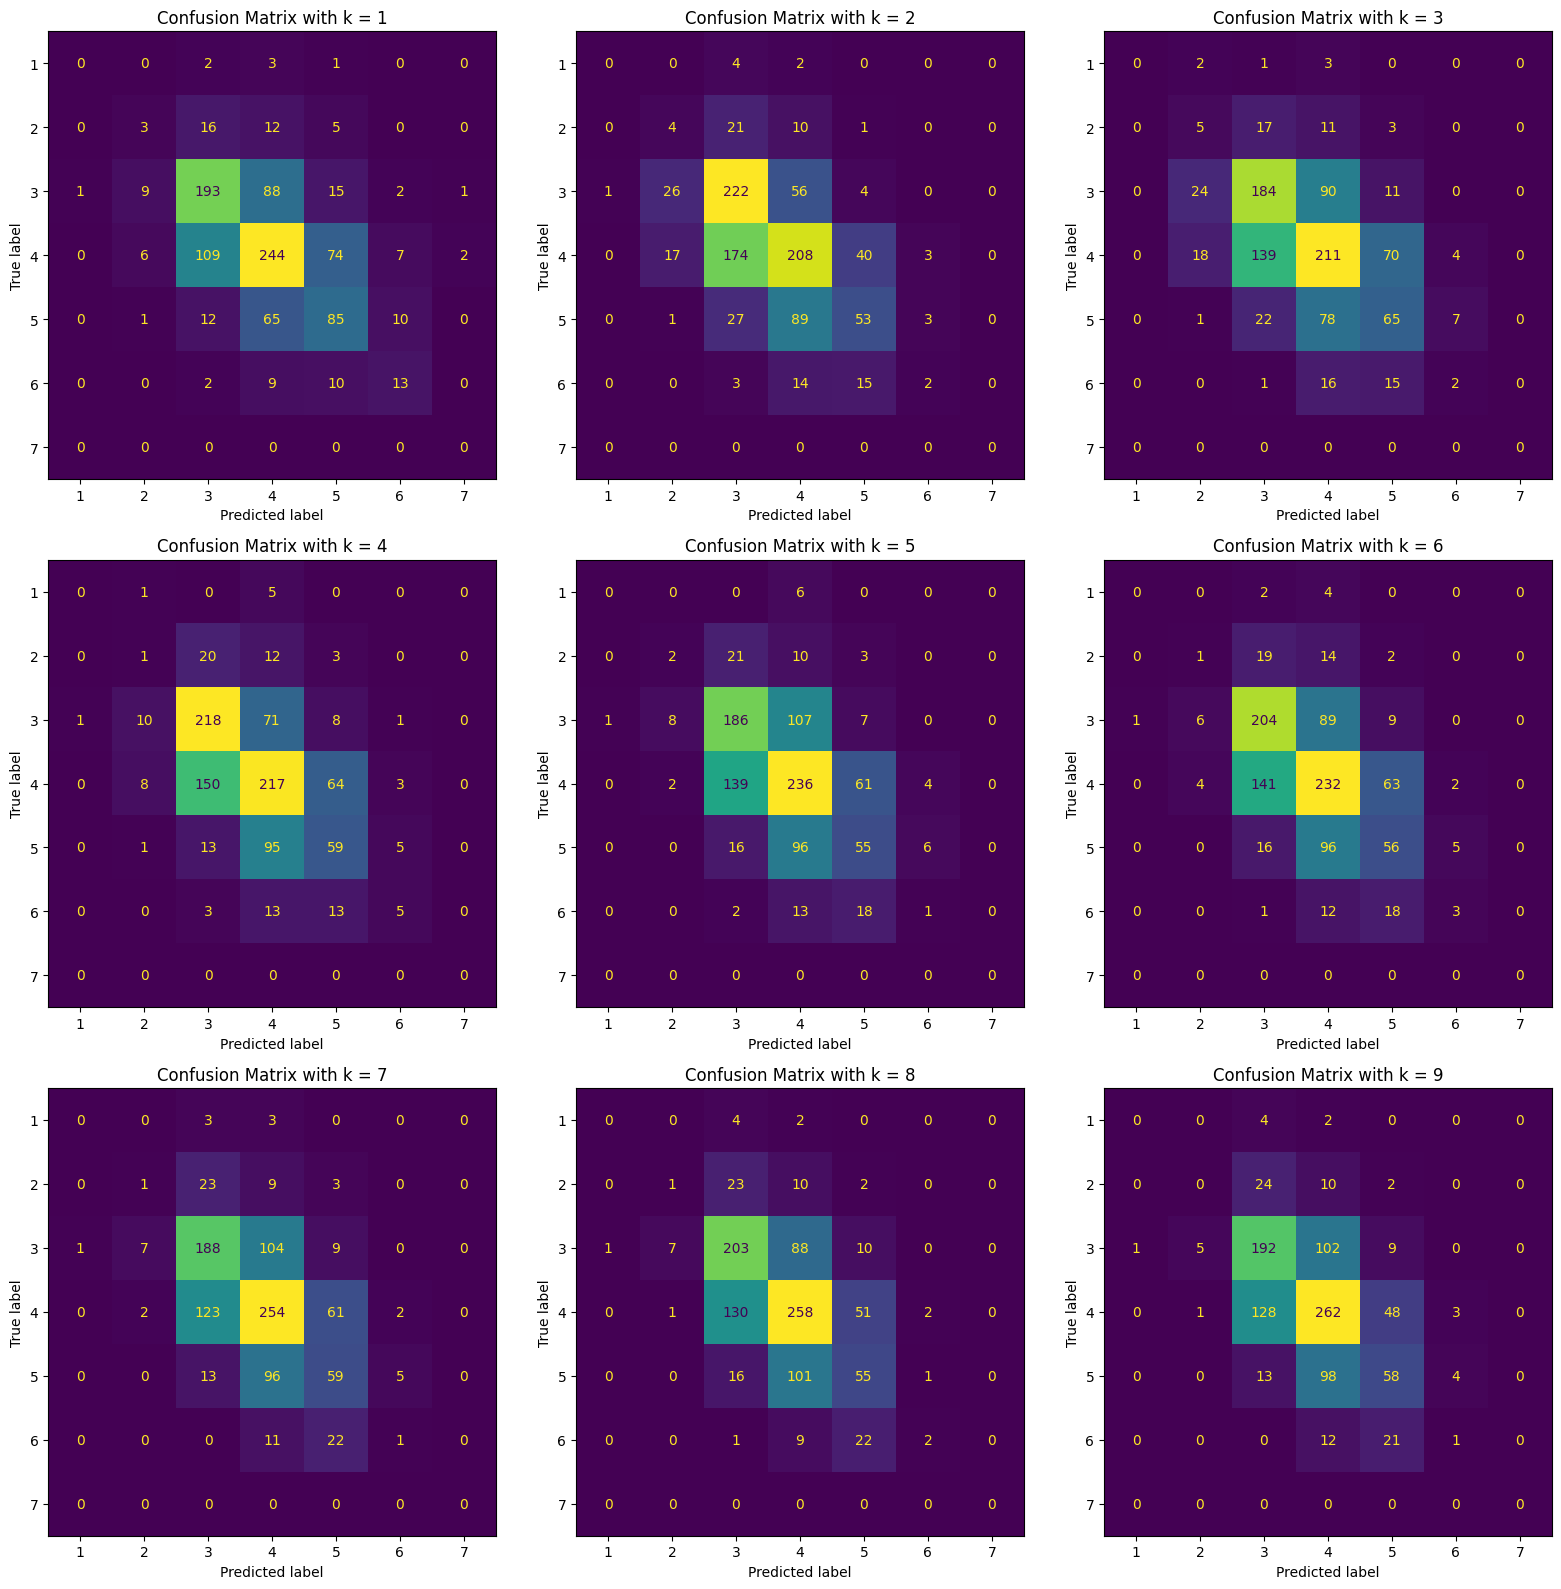

In [55]:
preds = np.zeros_like(y_test)
accuracies = []
k_values = range(1, 10)     # 1 to 9

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]
    nearest_labels = dists[:, :K_VALUE, 1]
    
    preds_res = stats.mode(nearest_labels, keepdims=True, axis=1)
    preds = np.array(preds_res)[0, ...]
    
    cm = confusion_matrix(y_test, preds, labels=classes)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=classes, )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    accuracies.append(np.sum(np.trace(cm)) / len(preds) * 100)
    
plt.tight_layout()
plt.show()

(0.0, 100.0)

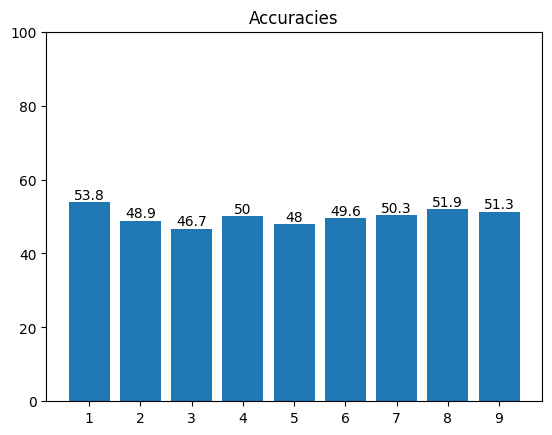

In [56]:
# Accuracies
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars)
plt.title('Accuracies')
plt.xticks(k_values)
plt.ylim((0,100))